In [18]:
import torch
import torchvision
import matplotlib.pyplot as plt

## データの読み込み

In [19]:
# MNISTデータの読み込み
data = torchvision.datasets.MNIST("data", train=True, download=False)

## データの基本情報調査

In [52]:
type(data)

torchvision.datasets.mnist.MNIST

In [20]:
# 長さを調べる
len(data)

60000

In [24]:
# 1件だけ見る
data[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

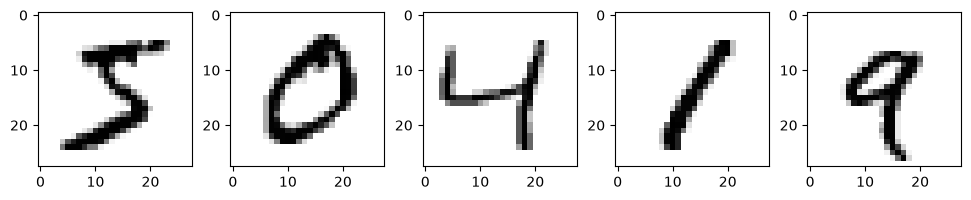

In [47]:
# 最初の5データを可視化する
fig, axs = plt.subplots(1, 5, figsize=(12, 2))

for i, ax in enumerate(axs):
    ax.imshow(data[i][0], cmap='gray_r')

plt.show()

In [49]:
# 形状を確認
data.data.shape

torch.Size([60000, 28, 28])

In [50]:
# 画素値の型
data.data.dtype

torch.uint8

In [51]:
# ラベルの形状
data.targets.shape

torch.Size([60000])

In [54]:
# ラベルのユニーク値確認
data.targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [57]:
# 画素値の範囲
data.data.min(), data.data.max()

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

In [59]:
# クラス名一覧
data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## transformerを適用してのデータの再読み込み

In [93]:
transformer = torchvision.transforms.ToTensor()
train_ds = torchvision.datasets.MNIST(
    "data", 
    train=True, 
    download=False, 
    transform=transformer # transformを指定することでPIL.Imageからtensorへ変換
)
test_ds = torchvision.datasets.MNIST(
    "data", 
    train=False, 
    download=False, 
    transform=transformer
)

In [94]:
# データの確認
print(type(train_ds))
print(len(train_ds))
print(train_ds.data.shape)
print(train_ds.data.dtype)
print(train_ds.targets.shape)
print(train_ds.targets.unique())
print(train_ds.data.min(), train_ds.data.max())
print(train_ds.classes)

<class 'torchvision.datasets.mnist.MNIST'>
60000
torch.Size([60000, 28, 28])
torch.uint8
torch.Size([60000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [95]:
# データの確認
print(type(test_ds))
print(len(test_ds))
print(test_ds.data.shape)
print(test_ds.data.dtype)
print(test_ds.targets.shape)
print(test_ds.targets.unique())
print(test_ds.data.min(), test_ds.data.max())
print(test_ds.classes)

<class 'torchvision.datasets.mnist.MNIST'>
10000
torch.Size([10000, 28, 28])
torch.uint8
torch.Size([10000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## DataLoaderでバッチ化

In [96]:
from torch.utils.data import DataLoader
batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [106]:
# データの確認
print(type(train_dl))
print(len(train_dl))

<class 'torch.utils.data.dataloader.DataLoader'>
1875


In [116]:
images, labels = next(iter(train_dl))

# 形状確認
print(images.shape)
print(images.dtype)
print(images.min(), images.max())

torch.Size([32, 1, 28, 28])
torch.float32
tensor(0.) tensor(1.)


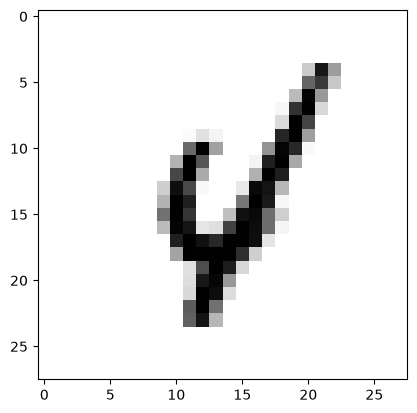

In [121]:
# 1枚取り出して描画
plt.imshow(images[0][0], cmap='gray_r')
plt.show()